In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df= pd.read_csv('dubai.csv')

In [3]:
df.shape

(5058, 12)

In [4]:
df.sample(5)

,title,displayAddress,bathrooms,bedrooms,addedOn,type,price,verified,priceDuration,sizeMin,furnishing,description
906,Rare Available | Difc View | Vacant,"Sky Gardens, DIFC, Dubai",3,2,2024-07-31T13:28:39Z,Residential for Sale,2850000,True,sell,1701 sqft,NO,Sky Gardens Tower\n\nProperty Info:\n- 2 Bedro...
2771,Handover Soon | Prime Location | PP | Resale,"The Fields at D11 - MBRMC, District 11, Mohamm...",4,4,2024-07-18T11:09:51Z,Residential for Sale,3999999,True,sell,2773 sqft,NO,"4 beds + maid\nPlot Area: 2,020 sqft.\nBUA : 2..."
3953,Falcon - 3 Bed+M | Beach Access | Luxury Lifes...,"Beach Homes, Falcon Island, Al Hamra Village, ...",4,3,2024-08-10T18:55:37Z,Residential for Sale,2800000,False,sell,2110 sqft,NO,Glasshouse Properties FZ-LLC is presents a bea...
1492,High Floor | Tenanted | Spacious-24/7 security,"Al Manara, Jumeirah Village Triangle, Dubai",1,1,2024-03-26T08:07:32Z,Residential for Sale,950000,True,sell,779 sqft,NO,fäm Properties is delighted to introduce this ...
3760,Unique Designs | Aspirational Lifestyle,"Orchid, Creek Beach, Dubai Creek Harbour (The ...",1,1,2024-08-16T10:41:37Z,Residential for Sale,1500000,True,sell,690 sqft,NO,SB CAPITAL is delighted to extend a warm welco...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5058 entries, 0 to 5057
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           5058 non-null   object
 1   displayAddress  5058 non-null   object
 2   bathrooms       4938 non-null   object
 3   bedrooms        4935 non-null   object
 4   addedOn         5058 non-null   object
 5   type            5058 non-null   object
 6   price           5058 non-null   int64 
 7   verified        5058 non-null   bool  
 8   priceDuration   5058 non-null   object
 9   sizeMin         5058 non-null   object
 10  furnishing      5056 non-null   object
 11  description     5057 non-null   object
dtypes: bool(1), int64(1), object(10)
memory usage: 439.7+ KB


In [6]:
df.isnull().sum()

title               0
displayAddress      0
bathrooms         120
bedrooms          123
addedOn             0
type                0
price               0
verified            0
priceDuration       0
sizeMin             0
furnishing          2
description         1
dtype: int64

In [7]:
df.describe()

,price
count,5.058000e+03
mean,5.050924e+06
std,1.000928e+07
min,1.000000e+05
25%,1.200000e+06
50%,2.350000e+06
75%,4.499375e+06
max,1.990000e+08


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print(df['bedrooms'].unique()[:20])
print(df['bathrooms'].unique()[:20])
print(df['sizeMin'].unique()[:20])

['2' '4' '3' '5' '1' 'studio' nan '7' '6' '7+']
['3' '7' '4' '1' '5' '2' '6' nan '7+' 'none']
['1323 sqft' '1410 sqft' '2324 sqft' '1647 sqft' '2105 sqft' '7059 sqft'
 '1095 sqft' '1991 sqft' '1881 sqft' '669 sqft' '3970 sqft' '2204 sqft'
 '1188 sqft' '2176 sqft' '654 sqft' '2555 sqft' '909 sqft' '2036 sqft'
 '6820 sqft' '444 sqft']


In [10]:
df['bedrooms'] = (
    df['bedrooms']
    .replace({'studio': 0, '7+': 7})
    .astype(float)
)

In [11]:
df['bathrooms'] = (
    df['bathrooms']
    .replace({'7+': 7, 'none': 0})
    .astype(float)
)

In [12]:
df['sizeMin'] = (
    df['sizeMin']
    .str.replace('sqft', '', regex=True)
    .str.replace(',', '', regex=True)
    .str.strip()
    .astype(float)
)

<Axes: xlabel='furnishing'>

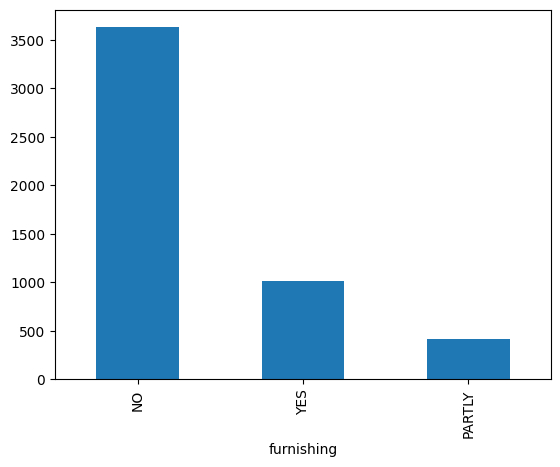

In [13]:
#sns.countplot(df['furnishing'])
df['furnishing'].value_counts().plot(kind='bar')

<Axes: xlabel='verified'>

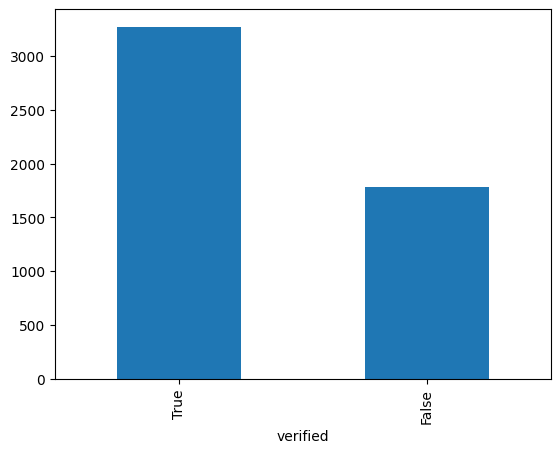

In [14]:
df['verified'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

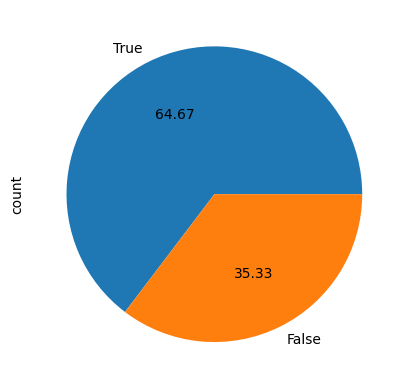

In [15]:
df['verified'].value_counts().plot(kind='pie' , autopct='%.2f')

<Axes: ylabel='count'>

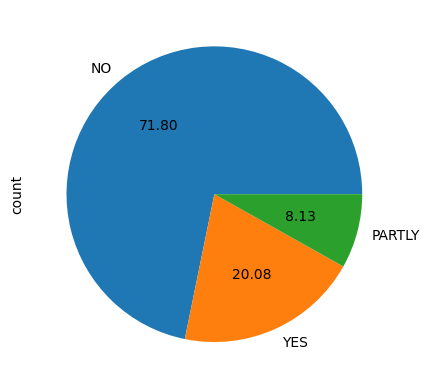

In [16]:
df['furnishing'].value_counts().plot(kind='pie' , autopct='%.2f')

In [17]:
import matplotlib.pyplot as plt

(array([ 541., 1265., 1088.,    0.,  799.,  714.,    0.,  366.,  122.,
          40.]),
 array([0. , 0.7, 1.4, 2.1, 2.8, 3.5, 4.2, 4.9, 5.6, 6.3, 7. ]),
 <BarContainer object of 10 artists>)

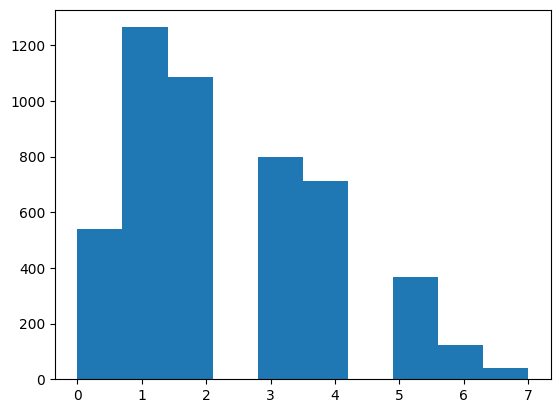

In [18]:
plt.hist(df['bedrooms'])

/tmp/ipykernel_9051/3725469546.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedrooms'])


<Axes: xlabel='bedrooms', ylabel='Density'>

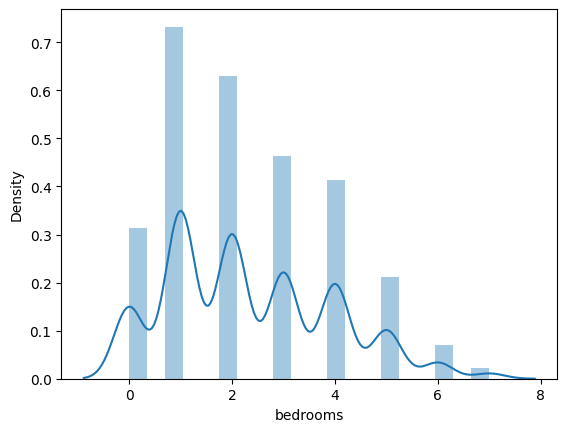

In [19]:
sns.distplot(df['bedrooms'])

<Axes: ylabel='bedrooms'>

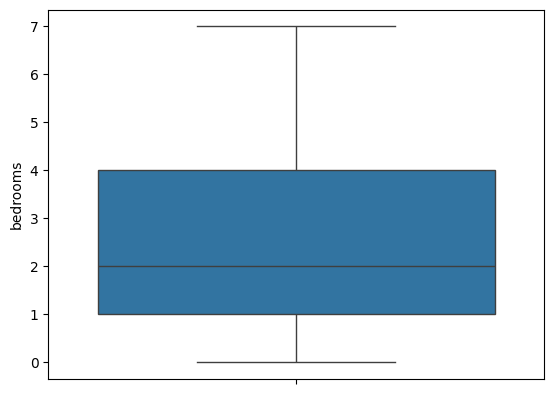

In [20]:
sns.boxplot(df['bedrooms'])

In [21]:
df['bedrooms'].max()

np.float64(7.0)

In [22]:
df['bedrooms'].min()

np.float64(0.0)

In [23]:
df['bedrooms'].skew

<bound method Series.skew of 0       2.0
1       2.0
2       4.0
3       2.0
4       3.0
       ... 
5053    2.0
5054    1.0
5055    4.0
5056    2.0
5057    4.0
Name: bedrooms, Length: 5058, dtype: float64>

## till now we did univeriate analysis

<Axes: xlabel='bedrooms', ylabel='bathrooms'>

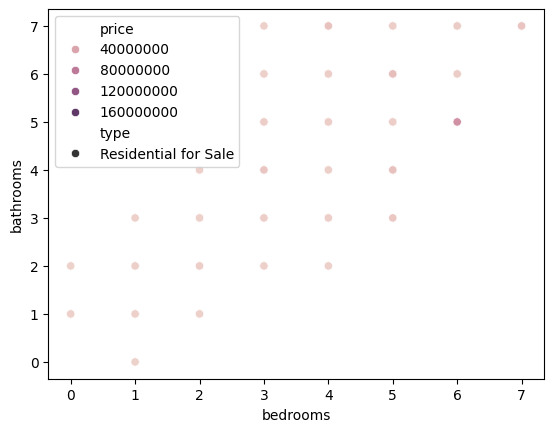

In [24]:
sns.scatterplot(data=df, x="bedrooms", y="bathrooms", hue="price", style="type")